In [1]:
import torch
import cv2
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")

model = YOLO("yolov8s.pt")
print("Model loaded successfully")

PyTorch version: 2.11.0
GPU available:   False
Model loaded successfully


In [2]:
# test cell - technically is optional
import urllib.request

urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "test_image.jpg")

results = model("test_image.jpg")
result  = results[0]

print("Quick test — objects found:")
for box in result.boxes:
    class_name = result.names[int(box.cls)]
    confidence = round(float(box.conf) * 100, 1)
    print(f"  - {class_name}: {confidence}%")


image 1/1 /Users/birat/Desktop/COM3025-CW/backend/tests/notebooks/test_image.jpg: 640x480 4 persons, 1 bus, 88.0ms
Speed: 7.1ms preprocess, 88.0ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 480)
Quick test — objects found:
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%


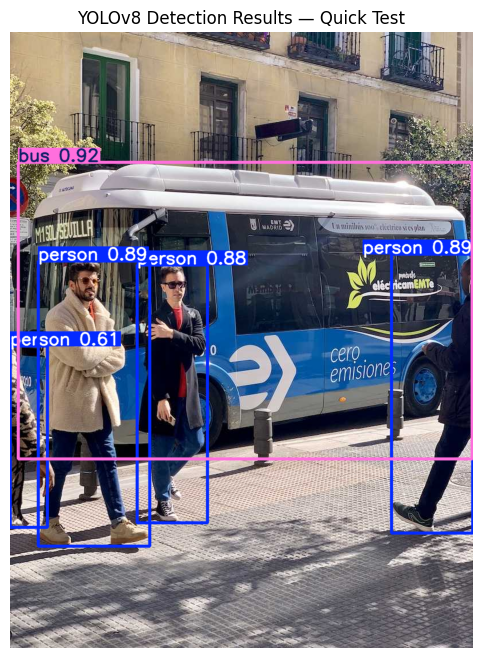

In [3]:
import matplotlib.pyplot as plt

annotated_image     = result.plot()
annotated_image_rgb = annotated_image[:, :, ::-1]  # fix BGR to RGB for display

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis("off")
plt.title("YOLOv8 Detection Results — Quick Test")
plt.show()

In [4]:
CONFIDENCE_THRESHOLD = 0.5

print(f"Detections above {CONFIDENCE_THRESHOLD * 100}% confidence:")
print("-" * 40)

kept    = 0
removed = 0

for box in result.boxes:
    confidence = float(box.conf)
    class_name = result.names[int(box.cls)]

    if confidence < CONFIDENCE_THRESHOLD:
        removed += 1
        continue

    print(f"  - {class_name}: {round(confidence * 100, 1)}%")
    kept += 1

print("-" * 40)
print(f"Kept: {kept} detections ")
print(f"Removed: {removed} low-confidence detections")

Detections above 50.0% confidence:
----------------------------------------
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%
----------------------------------------
Kept: 5 detections 
Removed: 0 low-confidence detections


In [5]:
import os

output_path = "detection_result.jpg"
annotated_save = result.plot()
cv2.imwrite(output_path, annotated_save)

print(f"Saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Saved to: detection_result.jpg
File size: 361856 bytes


In [7]:
def run_detection(image_path, confidence=0.5, save_result=True):
    results          = model(image_path, conf=confidence, verbose=False)
    result           = results[0]
    detected_objects = [result.names[int(b.cls)] for b in result.boxes]
    annotated_image  = result.plot()
    result_path      = None

    if save_result:
        result_path = image_path.replace(".jpg", "_detected.jpg")
        cv2.imwrite(result_path, annotated_image)

    return detected_objects, annotated_image, result_path


# Quick test of the function
import os
if os.path.exists("test_image.jpg"):
    objects, image, saved = run_detection("test_image.jpg")
    print("run_detection() works correctly")
    print(f"Detected: {objects}")
else:
    print("run_detection() defined — run Cell 3 first to test it")

run_detection() works correctly
Detected: ['bus', 'person', 'person', 'person', 'person']


In [9]:
# Spatial description helpers
# Adds position and distance to each detection.
# Takes a YOLO bounding box and image dimensions and returns position, distance, and a formatted description string.
def get_spatial_description(box, image_width, image_height):

    x1, y1, x2, y2 = box.xyxy[0].tolist()
    box_centre_x    = (x1 + x2) / 2
    box_width       = x2 - x1
    box_height      = y2 - y1

    # Position
    if box_centre_x < image_width * 0.33:
        position = "left"
    elif box_centre_x > image_width * 0.66:
        position = "right"
    else:
        position = "centre"

    # Distance
    size_ratio = (box_width * box_height) / (image_width * image_height)

    if size_ratio > 0.40:
        distance = "close up"
    elif size_ratio > 0.10:
        distance = "mid-range"
    else:
        distance = "far away"

    description = f"on the {position}, {distance}"
    return position, distance, description

# Runs YOLO and adds spatial descriptions to each detection.
def run_detection_with_spatial(image_path, confidence=0.5):
    from PIL import Image as PILImage

    img          = PILImage.open(image_path)
    image_width  = img.width
    image_height = img.height

    results   = model(image_path, conf=confidence, verbose=False)
    result    = results[0]
    annotated = result.plot()

    descriptions = []
    for box in result.boxes:
        class_name             = result.names[int(box.cls)]
        position, distance, spatial = get_spatial_description(box, image_width, image_height)
        descriptions.append(f"{class_name} {spatial}")

    return descriptions, annotated


# small test
import os
if os.path.exists("../data/coco_test/000000000139.jpg"):
    descriptions, annotated = run_detection_with_spatial("../data/coco_test/000000000139.jpg")
    print("Spatial detection test:")
    for d in descriptions:
        print(f"  - {d}")
else:
    print("run_detection_with_spatial() defined — ready to use")

run_detection_with_spatial() defined — ready to use


Camera opened — capturing photo in 2 seconds...
Photo captured


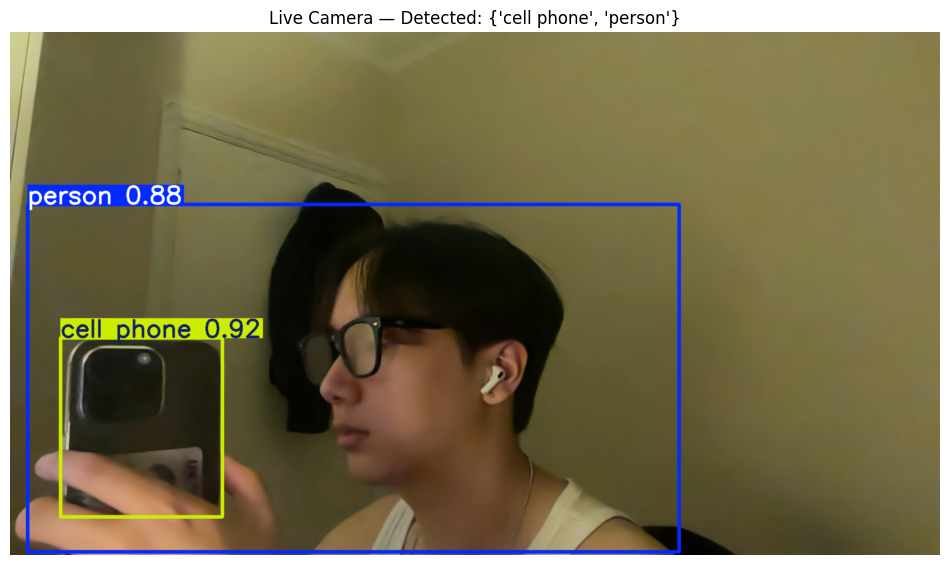

Objects found: ['cell phone', 'person']


In [24]:
import cv2
import matplotlib.pyplot as plt

# Open the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam — check it is connected and not in use")
else:
    print("Camera opened — capturing photo in 2 seconds...")

    # Let the camera warm up — read a few frames first
    for _ in range(10):
        cap.read()

    # Take the actual photo
    success, frame = cap.read()
    cap.release()  # always release the camera when done

    if not success:
        print("Failed to capture photo — try running the cell again")
    else:
        # Save the captured frame
        cv2.imwrite("camera_capture.jpg", frame)
        print("Photo captured")

        # Run detection
        objects, annotated, saved = run_detection("camera_capture.jpg")

        # Display result
        annotated_rgb = annotated[:, :, ::-1]
        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_rgb)
        plt.axis("off")
        plt.title(f"Live Camera — Detected: {set(objects)}")
        plt.show()

        print(f"Objects found: {objects}")

# basic detection done, COCO dataset detection below


In [25]:
import csv
import json
import os
import time

IMAGE_FOLDER     = "../coco_indoor"
ANNOTATIONS_PATH = "../coco_indoor/selected_instances.json"
RESULTS_FILE     = "detection_results.csv"
CONFIDENCE       = 0.5

# Load ground truth labels
with open(ANNOTATIONS_PATH) as f:
    ground_truth = json.load(f)

selected_images = list(ground_truth.keys())
print(f"Images to process: {len(selected_images)}")
print(f"Sample: {selected_images[:3]}\n")

# Set up CSV
with open(RESULTS_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

print(f"Running detection on {len(selected_images)} images...")
print("-" * 50)

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = model(image_path, conf=CONFIDENCE, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects    = ground_truth[filename]

    with open(RESULTS_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/{len(selected_images)} — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Done. Results saved to {RESULTS_FILE}")

Images to process: 20
Sample: ['000000010363.jpg', '000000007574.jpg', '000000003156.jpg']

Running detection on 20 images...
--------------------------------------------------
  1/20 — 000000010363.jpg — found 3 — GT had 4 — 157.0ms
  2/20 — 000000007574.jpg — found 9 — GT had 8 — 114.1ms
  3/20 — 000000003156.jpg — found 2 — GT had 3 — 77.2ms
  4/20 — 000000006818.jpg — found 2 — GT had 1 — 60.1ms
  5/20 — 000000006213.jpg — found 0 — GT had 1 — 60.9ms
  6/20 — 000000013659.jpg — found 15 — GT had 6 — 128.7ms
  7/20 — 000000001353.jpg — found 3 — GT had 2 — 81.2ms
  8/20 — 000000005193.jpg — found 10 — GT had 3 — 63.7ms
  9/20 — 000000000139.jpg — found 7 — GT had 10 — 74.6ms
  10/20 — 000000012576.jpg — found 14 — GT had 7 — 79.6ms
  11/20 — 000000003934.jpg — found 7 — GT had 5 — 66.3ms
  12/20 — 000000000632.jpg — found 5 — GT had 4 — 66.2ms
  13/20 — 000000001993.jpg — found 3 — GT had 3 — 57.6ms
  14/20 — 000000007795.jpg — found 2 — GT had 3 — 57.6ms
  15/20 — 000000009483.jpg 

In [26]:
import csv

total_detections = 0
all_times = []
object_counts = []

with open(RESULTS_FILE) as f:
    reader = csv.DictReader(f)
    for row in reader:
        total_detections += int(row["num_detections"])
        all_times.append(float(row["processing_time_ms"]))
        object_counts.append(int(row["num_detections"]))

total_images = len(object_counts)

print("── Results Summary ──────────────────")
print(f"Images processed:      {total_images}")
print(f"Total detections:      {total_detections}")
print(f"Avg detections/image:  {round(total_detections/total_images, 1)}")
print(f"Avg processing time:   {round(sum(all_times)/len(all_times), 1)}ms")
print(f"Fastest image:         {min(all_times)}ms")
print(f"Slowest image:         {max(all_times)}ms")
print(f"Most objects in one image: {max(object_counts)}")
print(f"Images with 0 detections:  {object_counts.count(0)}")

── Results Summary ──────────────────
Images processed:      20
Total detections:      118
Avg detections/image:  5.9
Avg processing time:   76.2ms
Fastest image:         55.3ms
Slowest image:         157.0ms
Most objects in one image: 15
Images with 0 detections:  1


In [23]:
# baseline comparison
import csv
import time
import os

BASELINE_FILE  = "../data/baseline_results.csv"
baseline_model = YOLO("yolov8n.pt")  # smaller, less accurate model

print("Running baseline detection (YOLOv8n, no confidence filter)...")
print("-" * 50)

with open(BASELINE_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = baseline_model(image_path, conf=0.0, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects    = ground_truth[filename]

    with open(BASELINE_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/50 — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Baseline done. Results saved to {BASELINE_FILE}")

Running baseline detection (YOLOv8n, no confidence filter)...
--------------------------------------------------
  1/50 — 000000002592.jpg — found 300 — GT had 3 — 66.2ms
  2/50 — 000000003845.jpg — found 300 — GT had 6 — 71.0ms
  3/50 — 000000002532.jpg — found 300 — GT had 2 — 76.6ms
  4/50 — 000000003156.jpg — found 300 — GT had 3 — 65.5ms
  5/50 — 000000003661.jpg — found 300 — GT had 3 — 51.1ms
  6/50 — 000000001761.jpg — found 300 — GT had 2 — 70.5ms
  7/50 — 000000005037.jpg — found 300 — GT had 3 — 69.8ms
  8/50 — 000000001532.jpg — found 300 — GT had 2 — 73.2ms
  9/50 — 000000001584.jpg — found 300 — GT had 2 — 106.3ms
  10/50 — 000000002149.jpg — found 300 — GT had 2 — 58.4ms
  11/50 — 000000002923.jpg — found 300 — GT had 2 — 82.8ms
  12/50 — 000000001268.jpg — found 300 — GT had 6 — 73.2ms
  13/50 — 000000004795.jpg — found 300 — GT had 3 — 62.2ms
  14/50 — 000000002006.jpg — found 300 — GT had 4 — 71.0ms
  15/50 — 000000001353.jpg — found 300 — GT had 2 — 71.2ms
  16/50 — 

In [24]:
# Spatial Logic Evaluation
# Evaluates how accurately our spatial descriptions match human annotations.
# Tests position (left/centre/right) and distance (close up/mid-range/far away) on 10 manually annotated real-world photos.

import json
import os
from PIL import Image as PILImage

SPATIAL_IMAGES_FOLDER = "../data/eval_images"
SPATIAL_GT_PATH       = "../data/annotations/eval10_annotations.json"

# Name mapping - YOLO was trained on 80 COCO classes — some of our annotated objects fall outside those classes so we map them to the closest equivalent.

NAME_MAP = {
    "bag":      ["handbag", "backpack", "suitcase"],
    "food":     ["bowl", "cup", "fork", "spoon", "knife", "dining table"],
    "pigeon":   ["bird"],
    "swan":     ["bird"],
    "clothes":  ["person"],
    "pot":      ["vase", "bowl"],
    "box":      ["suitcase", "backpack"],
    "sofa":     ["couch"],
    "plant":    ["potted plant", "vase"],
    "receipt":  ["book"],
    "guitar":   ["guitar"],
    "printer":  ["laptop"],
    "glasses":  ["sunglasses"],
    "monitor":  ["tv"],
    "speaker":  ["tv"],
    "pen":      ["knife"],
    "tree":     ["potted plant"],
}

def normalise_name(name):
    name = name.lower()
    if name in NAME_MAP:
        return NAME_MAP[name]
    return [name]


# Load ground truth
with open(SPATIAL_GT_PATH) as f:
    ground_truth = json.load(f)

print(f"Loaded annotations for {len(ground_truth)} images")
print("=" * 60)

# Run evaluation
total_gt_objects       = 0
total_position_correct = 0
total_distance_correct = 0
total_both_correct     = 0
total_detected         = 0
total_missed           = 0

for filename, gt_annotations in ground_truth.items():
    image_path = os.path.join(SPATIAL_IMAGES_FOLDER, filename)

    if not os.path.exists(image_path):
        print(f"SKIPPING {filename} — not found in {SPATIAL_IMAGES_FOLDER}")
        continue

    img          = PILImage.open(image_path)
    image_width  = img.width
    image_height = img.height

    results    = model(image_path, conf=0.5, verbose=False)
    result     = results[0]

    # build YOLO detections with spatial info
    yolo_detections = []
    for box in result.boxes:
        class_name             = result.names[int(box.cls)]
        position, distance, _  = get_spatial_description(box, image_width, image_height)
        yolo_detections.append({
            "class":    class_name.lower(),
            "position": position,
            "distance": distance
        })

    # compare each ground truth object against YOLO detections
    image_position_correct = 0
    image_distance_correct = 0
    image_both_correct     = 0
    image_detected         = 0
    image_missed           = 0

    for gt in gt_annotations:
        gt_obj           = gt["object"].lower()
        gt_position      = gt["position"]
        gt_distance      = gt["distance"]
        acceptable_names = normalise_name(gt_obj)

        # find first YOLO detection whose class matches
        best_match = None
        for det in yolo_detections:
            if det["class"] in acceptable_names:
                best_match = det
                break

        if best_match is None:
            image_missed += 1
        else:
            image_detected += 1
            pos_correct  = best_match["position"] == gt_position
            dist_correct = best_match["distance"] == gt_distance

            if pos_correct:
                image_position_correct += 1
            if dist_correct:
                image_distance_correct += 1
            if pos_correct and dist_correct:
                image_both_correct += 1

    total_gt_objects       += len(gt_annotations)
    total_position_correct += image_position_correct
    total_distance_correct += image_distance_correct
    total_both_correct     += image_both_correct
    total_detected         += image_detected
    total_missed           += image_missed

    print(f"{filename}")
    print(f"  GT objects:       {len(gt_annotations)}")
    print(f"  YOLO detected:    {image_detected}   Missed: {image_missed}")
    if image_detected > 0:
        print(f"  Position correct: {image_position_correct}/{image_detected}")
        print(f"  Distance correct: {image_distance_correct}/{image_detected}")
        print(f"  Both correct:     {image_both_correct}/{image_detected}")
    print()

# Summary
print("=" * 60)
print("SPATIAL EVALUATION SUMMARY")
print("=" * 60)
print(f"Total annotated objects:   {total_gt_objects}")
print(f"Detected by YOLO:          {total_detected}")
print(f"Missed by YOLO:            {total_missed}")
print(f"Detection rate:            {round(total_detected / total_gt_objects * 100, 1)}%")
print()
if total_detected > 0:
    print(f"Position accuracy:         {round(total_position_correct / total_detected * 100, 1)}%")
    print(f"Distance accuracy:         {round(total_distance_correct / total_detected * 100, 1)}%")
    print(f"Full spatial accuracy:     {round(total_both_correct / total_detected * 100, 1)}%")
    print()
    print("Note: accuracy is calculated on detected objects only.")
    print("Missed objects are listed separately above.")
    print()
    print("Some objects were not detected because they fall outside")
    print("YOLO's 80 COCO classes (e.g. swan, pigeon, receipt).")
    print("These are counted as missed and noted as a system limitation.")

Loaded annotations for 10 images
01.jpg
  GT objects:       14
  YOLO detected:    12   Missed: 2
  Position correct: 4/12
  Distance correct: 6/12
  Both correct:     2/12

02.jpg
  GT objects:       7
  YOLO detected:    7   Missed: 0
  Position correct: 5/7
  Distance correct: 1/7
  Both correct:     1/7

03.jpg
  GT objects:       3
  YOLO detected:    3   Missed: 0
  Position correct: 1/3
  Distance correct: 1/3
  Both correct:     1/3

04.jpg
  GT objects:       5
  YOLO detected:    0   Missed: 5

05.jpg
  GT objects:       7
  YOLO detected:    3   Missed: 4
  Position correct: 2/3
  Distance correct: 1/3
  Both correct:     1/3

06.jpg
  GT objects:       6
  YOLO detected:    1   Missed: 5
  Position correct: 1/1
  Distance correct: 0/1
  Both correct:     0/1

07.jpg
  GT objects:       10
  YOLO detected:    8   Missed: 2
  Position correct: 2/8
  Distance correct: 6/8
  Both correct:     0/8

08.jpg
  GT objects:       7
  YOLO detected:    5   Missed: 2
  Position correct

In [25]:
# VIDEO MODE WITH TEMPORAL CONSISTENCY
# Continuously captures frames from the webcam and announces objects.
# Only speaks when something NEW appears, disappears, or gets closer.

import cv2
import time
import pyttsx3
from PIL import Image as PILImage

# TTS
# INTEGRATION NOTE FOR PERSON 2:
# Only replace the speak() function when their TTS is ready.
# Everything else stays the same.
def speak(text):
    engine = pyttsx3.init()
    engine.setProperty('rate', 150)
    engine.setProperty('volume', 1.0)
    engine.say(text)
    engine.runAndWait()


# Temporal consistency helpers
def get_object_key(class_name, position):
    return f"{class_name}_{position}"

def get_distance_order(distance):
    return {"far away": 0, "mid-range": 1, "close up": 2}.get(distance, 0)


# Priority ordering
# lower number = announced first
PRIORITY = {
    "car": 1, "truck": 1, "bus": 1, "motorcycle": 1, "bicycle": 1,
    "person": 2,
    "chair": 3, "bench": 3, "dining table": 3, "couch": 3,
    "bed": 3, "toilet": 3,
    "dog": 4, "cat": 4, "bottle": 4, "cup": 4,
}

def get_priority(class_name):
    return PRIORITY.get(class_name, 5)


# Main video loop
# Press Q in the video window to stop.

def run_video_mode(confidence=0.5):

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Could not open webcam — check camera permissions in System Settings")
        return

    print("Video mode started — press Q to stop")
    speak("Assistive vision started")

    # tracks what was in the last frame

    previous = {}

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to read frame")
            break

        # save frame for YOLO
        temp_path = "../data/current_frame.jpg"
        cv2.imwrite(temp_path, frame)

        img          = PILImage.open(temp_path)
        image_width  = img.width
        image_height = img.height

        results_raw = model(temp_path, conf=confidence, verbose=False)
        result_raw  = results_raw[0]

        # build current frame detections
        current = {}
        for box in result_raw.boxes:
            class_name             = result_raw.names[int(box.cls)]
            position, distance, _  = get_spatial_description(box, image_width, image_height)
            key                    = get_object_key(class_name, position)
            current[key] = {
                "class":    class_name,
                "position": position,
                "distance": distance
            }

        # find what changed
        new_objects    = []
        gone_objects   = []
        closer_objects = []

        for key, obj in current.items():
            if key not in previous:
                new_objects.append(obj)
            else:
                prev_dist = get_distance_order(previous[key]["distance"])
                curr_dist = get_distance_order(obj["distance"])
                if curr_dist > prev_dist:
                    closer_objects.append(obj)

        for key, obj in previous.items():
            if key not in current:
                gone_objects.append(obj)

        # sort new objects by priority
        new_objects.sort(key=lambda x: get_priority(x["class"]))

        # build announcements
        announcements = []
        for obj in new_objects:
            announcements.append(
                f"{obj['class']} on the {obj['position']}, {obj['distance']}"
            )
        for obj in closer_objects:
            announcements.append(f"{obj['class']} getting closer")
        for obj in gone_objects:
            announcements.append(f"{obj['class']} gone")

        if announcements:
            text = ". ".join(announcements)
            print(f"  → {text}")
            speak(text)

        previous = current

        annotated = result_raw.plot()
        cv2.imshow("Assistive Vision", annotated)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    speak("Assistive vision stopped")
    print("Video mode stopped")



run_video_mode()

Video mode started — press Q to stop
  → person on the centre, mid-range
  → bottle on the centre, far away
  → scissors on the right, far away. bottle gone
  → scissors gone
  → person on the left, far away. bottle on the centre, far away
  → scissors on the centre, far away. person gone. bottle gone
  → person gone
  → person on the centre, mid-range
  → scissors gone
  → person on the left, far away
Video mode stopped
